In [54]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt


In [55]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"

df_intermediario = pd.read_parquet(caminho_parquet)


In [56]:
print(df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE']].isnull().sum())
print(df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE']].isnull().sum())
print(df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD']].isnull().sum())



# 23169 nulos de 533 926,  4 % dos dados, será removido. 


VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE    23169
dtype: int64
VARIACAO SEGUNDA HORA ANTERIOR UMIDADE    23169
dtype: int64
VARIACAO TERCEIRA HORA ANTERIOR UMIDAD    23186
dtype: int64


In [57]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD'])

# VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE - Kmeans

In [59]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'].describe()

count    509384.000000
mean         19.129556
std         374.165060
min          -1.000000
25%           2.000000
50%           4.000000
75%           7.000000
max       10099.000000
Name: VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE, dtype: float64

In [60]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'].max()

10099.0

In [61]:
# Verificando os casos de maximo
colunas_selecionadas = ["VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE", "Umidade_max", "Umidade_min",'hora']

idx_max = df_intermediario["VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE"].idxmax()

# Selecionar as 5 linhas acima e abaixo do maior
df_maiores = df_intermediario.loc[max(0, idx_max - 5) : idx_max + 5, colunas_selecionadas]

df_maiores.head(10)


,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,Umidade_max,Umidade_min,hora
24058,4.0,96.0,92.0,14
24059,2.0,95.0,93.0,15
24060,1.0,94.0,93.0,16
24061,0.0,94.0,94.0,17
24062,4.0,97.0,93.0,18
24063,10099.0,100.0,-9999.0,19
24064,7.0,100.0,93.0,20
24065,10099.0,100.0,-9999.0,21
24066,1.0,99.0,98.0,22
24067,2.0,98.0,96.0,23


In [62]:
colunas_selecionadas = ["VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE", "Umidade_max", "Umidade_min", "hora"]

# Encontrar o índice do valor mínimo
idx_min = df_intermediario["VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE"].idxmin()

# Selecionar as 5 linhas acima e abaixo do menor valor
df_menores = df_intermediario.loc[max(0, idx_min - 5) : idx_min + 5, colunas_selecionadas]

df_menores.head(10)


,VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE,Umidade_max,Umidade_min,hora
462475,3.0,92.0,89.0,7
462476,3.0,65.0,62.0,9
462477,8.0,61.0,53.0,11
462478,11.0,58.0,47.0,12
462479,2.0,32.0,30.0,14
462480,-1.0,29.0,30.0,15
462481,4.0,31.0,27.0,16
462482,3.0,28.0,25.0,17
462483,2.0,25.0,23.0,18
462484,3.0,25.0,22.0,19


In [63]:
# Linhas negativas vão ser removidas, pois nao faz sentido Umidade_max < Umidade_min 

df_intermediario = df_intermediario[df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'] <= 100]
df_intermediario = df_intermediario[df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'] <= 100]
df_intermediario = df_intermediario[df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD'] <= 100]


df_intermediario = df_intermediario[df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'] >=0]
df_intermediario = df_intermediario[df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE'] >= 0]
df_intermediario = df_intermediario[df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD'] >= 0]


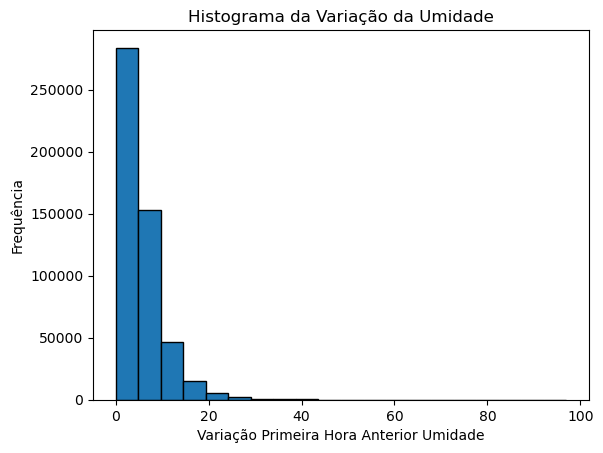

In [64]:

coluna = "VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE"

plt.hist(df_intermediario[coluna], bins= 20, edgecolor="black")
plt.xlabel("Variação Primeira Hora Anterior Umidade")
plt.ylabel("Frequência")
plt.title("Histograma da Variação da Umidade")
plt.show()


In [65]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE'].describe()

count    508302.000000
mean          5.155437
std           4.980416
min           0.000000
25%           2.000000
50%           4.000000
75%           7.000000
max          97.000000
Name: VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE, dtype: float64

In [66]:
'''
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE']]

silhouette_scores = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Índice de Silhueta')
plt.title('Índice de Silhueta para diferentes K')
plt.show()
'''

"\nX = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE']]\n\nsilhouette_scores = []\nK_range = range(2, 11)  \n\nfor k in K_range:\n    kmeans = KMeans(n_clusters=k, random_state=10)\n    labels = kmeans.fit_predict(X)\n    sil_score = silhouette_score(X, labels)\n    silhouette_scores.append(sil_score)\n\nplt.plot(K_range, silhouette_scores, marker='o')\nplt.xlabel('Número de Clusters')\nplt.ylabel('Índice de Silhueta')\nplt.title('Índice de Silhueta para diferentes K')\nplt.show()\n"

In [67]:
#################################################### 

In [68]:
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE']]

n_clusters = 3  

kmeans = KMeans(n_clusters = 3, random_state= 10)

df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters 
centroids = kmeans.cluster_centers_

print("Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS': ", centroids)

df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS'] = df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS'].map({
    0: 'baixo',      # Cluster com centróide 2.416
    1: 'medio',     # Cluster com 8.3020
    2: 'alto' ,     # Cluster com centróide 19.1638187      
})


Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS':  [[ 2.41693442]
 [ 8.30201311]
 [19.1638187 ]]


In [69]:
centroids_manual = np.array([
    [2.41693442],
    [8.30201311],
    [19.1638187]
])

In [70]:
X_novo = df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE']]

# Calcular a distância de cada ponto aos centróides e encontrar o cluster mais próximo
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS'] = np.argmin(
    cdist(X_novo, centroids_manual), axis=1
)

# Manter os mesmos rótulos de cluster
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS'
].map({
    0: 'baixo',      # Cluster com centróide 2.41693442
    1: 'medio',     # Cluster com 8.30201311
    2: 'Alto'      # Cluster com centróide 19.1638187
})

df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR UMIDADE', 
                        'VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS', 
                        'VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS']]

,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS,VARIACAO SEGUNDA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS
0,0.0,0,baixo
1,2.0,0,baixo
2,0.0,0,baixo
3,3.0,0,baixo
4,5.0,0,baixo
...,...,...,...
533921,5.0,0,baixo
533922,5.0,0,baixo
533923,4.0,0,baixo
533924,2.0,0,baixo


In [71]:
X_novo = df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD']]

# Calcular a distância de cada ponto aos centróides e encontrar o cluster mais próximo
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS'] = np.argmin(
    cdist(X_novo, centroids_manual), axis=1
)

# Manter os mesmos rótulos de cluster
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS'
].map({
    0: 'baixo',      # Cluster com centróide 2.41693442
    1: 'medio',     # Cluster com 8.30201311
    2: 'Alto'      # Cluster com centróide 19.1638187
})

df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR UMIDAD', 
                        'VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS', 
                        'VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS']]

,VARIACAO TERCEIRA HORA ANTERIOR UMIDAD,VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS,VARIACAO TERCEIRA HORA ANTERIOR UMIDADE CLUSTER K MEANS - ROTULOS
0,0.0,0,baixo
1,0.0,0,baixo
2,0.0,0,baixo
3,0.0,0,baixo
4,3.0,0,baixo
...,...,...,...
533921,4.0,0,baixo
533922,5.0,0,baixo
533923,5.0,0,baixo
533924,4.0,0,baixo


In [72]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"

df_intermediario.to_parquet(caminho_parquet, index=False)